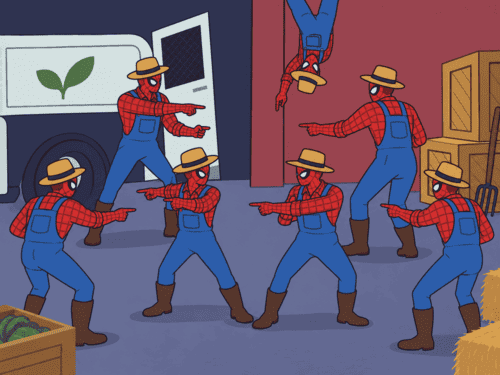

# 🕷️ Kaggriculture-Man: Reverse-Engineering Top-Agents Meta

### A replay laboratory, an exact agent map, and one bounded market-timing intervention

<div style="background:#171a14;color:#ffffff;border:4px solid #d1a256;border-radius:14px;padding:20px 24px;margin:20px 0">
  <div style="color:#d1a256;font-size:22px;font-weight:800;letter-spacing:.04em">BEFORE YOU CONTINUE</div>
  <p><b>If this work is useful, please upvote the notebook, download the companion datasets, and leave a concrete idea or counterexample in the comments.</b></p>
  <p>I can run the same diagnostics on public agents and public replays. Add a public notebook or episode link in the comments if you want its failure points mapped.</p>
  
  <p style="margin-bottom:0"><b>This notebook combines an article, a research instrument, and a reproducible agent build.</b> The analysis cells are not required to run the submitted agent.</p>
<p style="margin-bottom:12px;">
  <b>Related parts of this research:</b>
</p>

<p style="margin-bottom:6px;">
  <b>
    This part, covering the general overview and analysis is available here:
  </b>
</p>

<a href="https://www.kaggle.com/code/leoprovorov/kaggricult-man-reverse-engineering-part-1"
   target="_blank"
   style="
     display:inline-block;
     padding:10px 16px;
     margin-bottom:18px;
     background:#20BEFF;
     color:#000000;
     font-weight:700;
     text-decoration:none;
     border-radius:6px;
   ">
   → Open Part 1: General Overview & Analysis
</a>


<p style="margin-bottom:6px;">
  <b>
    The second part, focused on the possibility of hacking the in-game store, is available here:
  </b>
</p>

<a href="https://www.kaggle.com/code/leoprovorov/god-s-mode-hacked-stores/notebook?scriptVersionId=349839124"
   target="_blank"
   style="
     display:inline-block;
     padding:10px 16px;
     margin-bottom:18px;
     background:#20BEFF;
     color:#000000;
     font-weight:700;
     text-decoration:none;
     border-radius:6px;
   ">
   → Open Part 2: Hacking the Store

</a>



      
  <p style="margin-bottom:0"><b>Enjoy!</p>

## Mathematical model

Each formula is shown with its meaning and symbol definitions directly beside it.

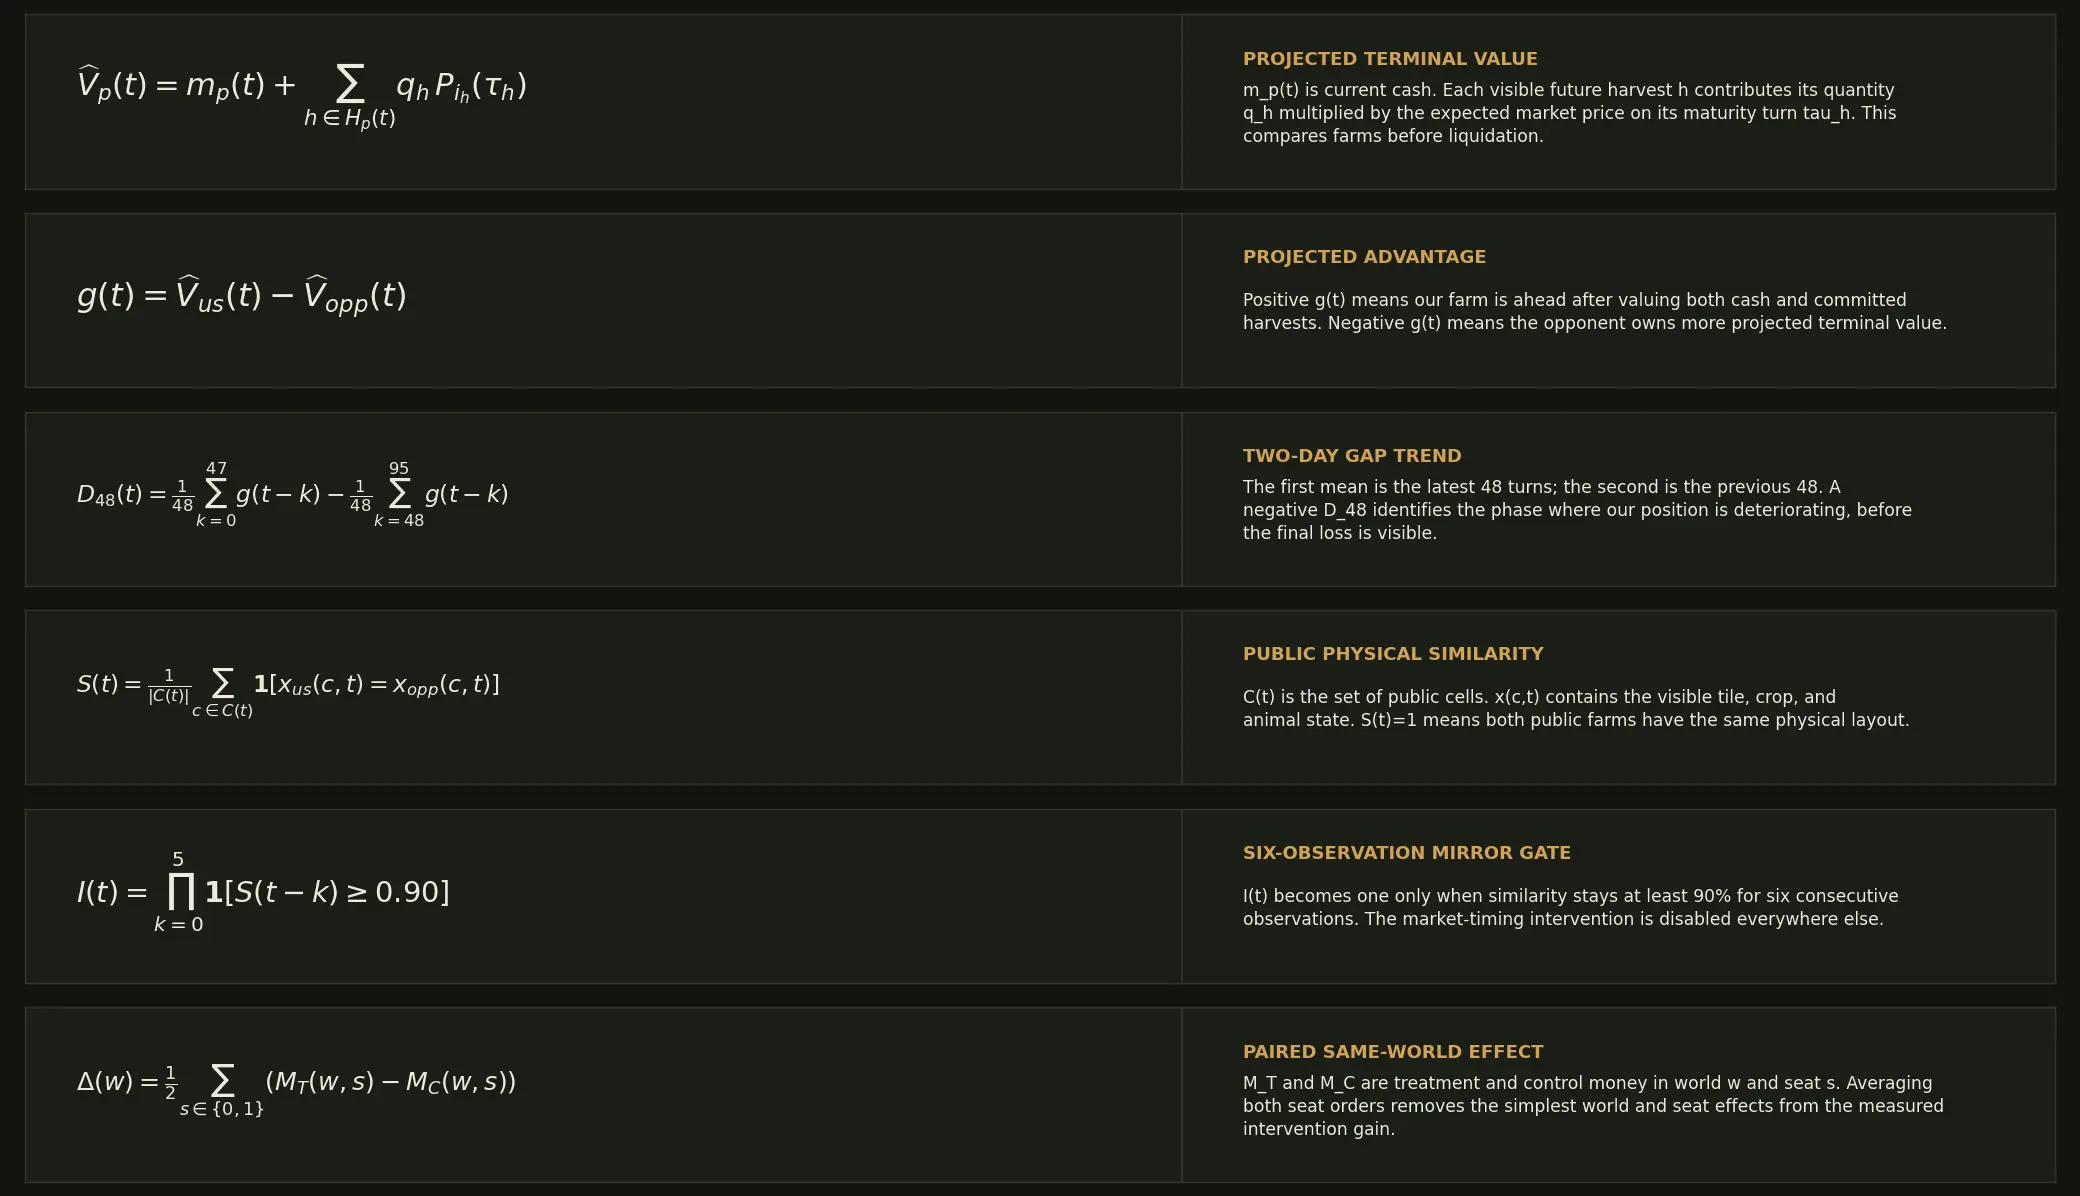

## Why the Spider-Man meme is not just a joke

Kaggriculture is unusually open. Competitors publish strong notebooks, and everyone can watch public replays of leading agents. This makes **behavioral reverse engineering** possible: not recovering source code, but reconstructing strategy from repeated observable actions.

Every strong public release becomes a base for the next participant. If a nearly optimal agent appears openly, many competitors can reuse it. The difference between first place and the thousandth participant may then become very small, while much of the work done by the original leaders stops being visible.

That is why I suggest upvoting every notebook with substantial individual work, even when it did not produce the strongest agent. The research effort should not disappear when somebody else turns it into a stronger public baseline.

The final evaluation is still uncertain, but not because Kaggriculture has a normal hidden private test partition. The competition uses continued agent matches and a final Bradley-Terry recomputation. The real unknown is the future opponent population: which agents remain active, how the public meta converges, and which matchups dominate the post-deadline evidence. See the official [Evaluation page](https://www.kaggle.com/competitions/kaggriculture/overview/evaluation).

> **Version update.** The submission is now **MarketShock-M1-WR1K**, with one audited day-21 local watering repair and exact parent pass-through everywhere else. The original experiment record below is unchanged.

## What was built

The base is a frozen Seven-Turn Rescue agent. The research layer reconstructs matches turn by turn and separates route selection from economic execution.

T4 adds one bounded mechanism. In likely mirror games it can sell selected parent-planned inventory one turn earlier. If a real probe shows that the opponent also preempts sales, the lead can become two turns. Every moved unit becomes a credit against the original sale, so the overlay cannot liquidate the same stock twice.

In three fixed worlds, lead-1 beat the untouched control in all six seat-swapped games. Adaptive lead-2 then beat lead-1 in all six. The crop-value guard added +196 in one world and exactly 0 in two, so I treat it as weak and world-specific rather than a general breakthrough.

```python
if mirror_gate_is_open and 336 <= step < 647:
    lead = 2 if counter_preemption_was_observed else 1
    for item, qty in parent_sales(step + lead):
        qty = min(qty, projected_shed[item])
        if 4 <= qty < 100 and market_order_slot_exists:
            sell_now(item, qty)
            credit_original_sale(item, qty)

parent_sale[item] -= credited_quantity[item]
```

The parent remains frozen. The intervention has a narrow gate, and every activation is logged.

## The full analysis surface

These are exact full-page captures from the live research server on 10 September 2026. They are not recreated charts and they do not use synthetic values.

**Field Ledger** finds the turn where value starts leaking. **Field Skeleton** exposes the agent's actual routing graph. **Field Worlds** measures all possible shop worlds and the replay coverage of each one.

## Field Ledger

One match, every economic layer: projected score, trend, market execution, revenue, spending, free cash, idle hands, planted value, and the final harvest book.

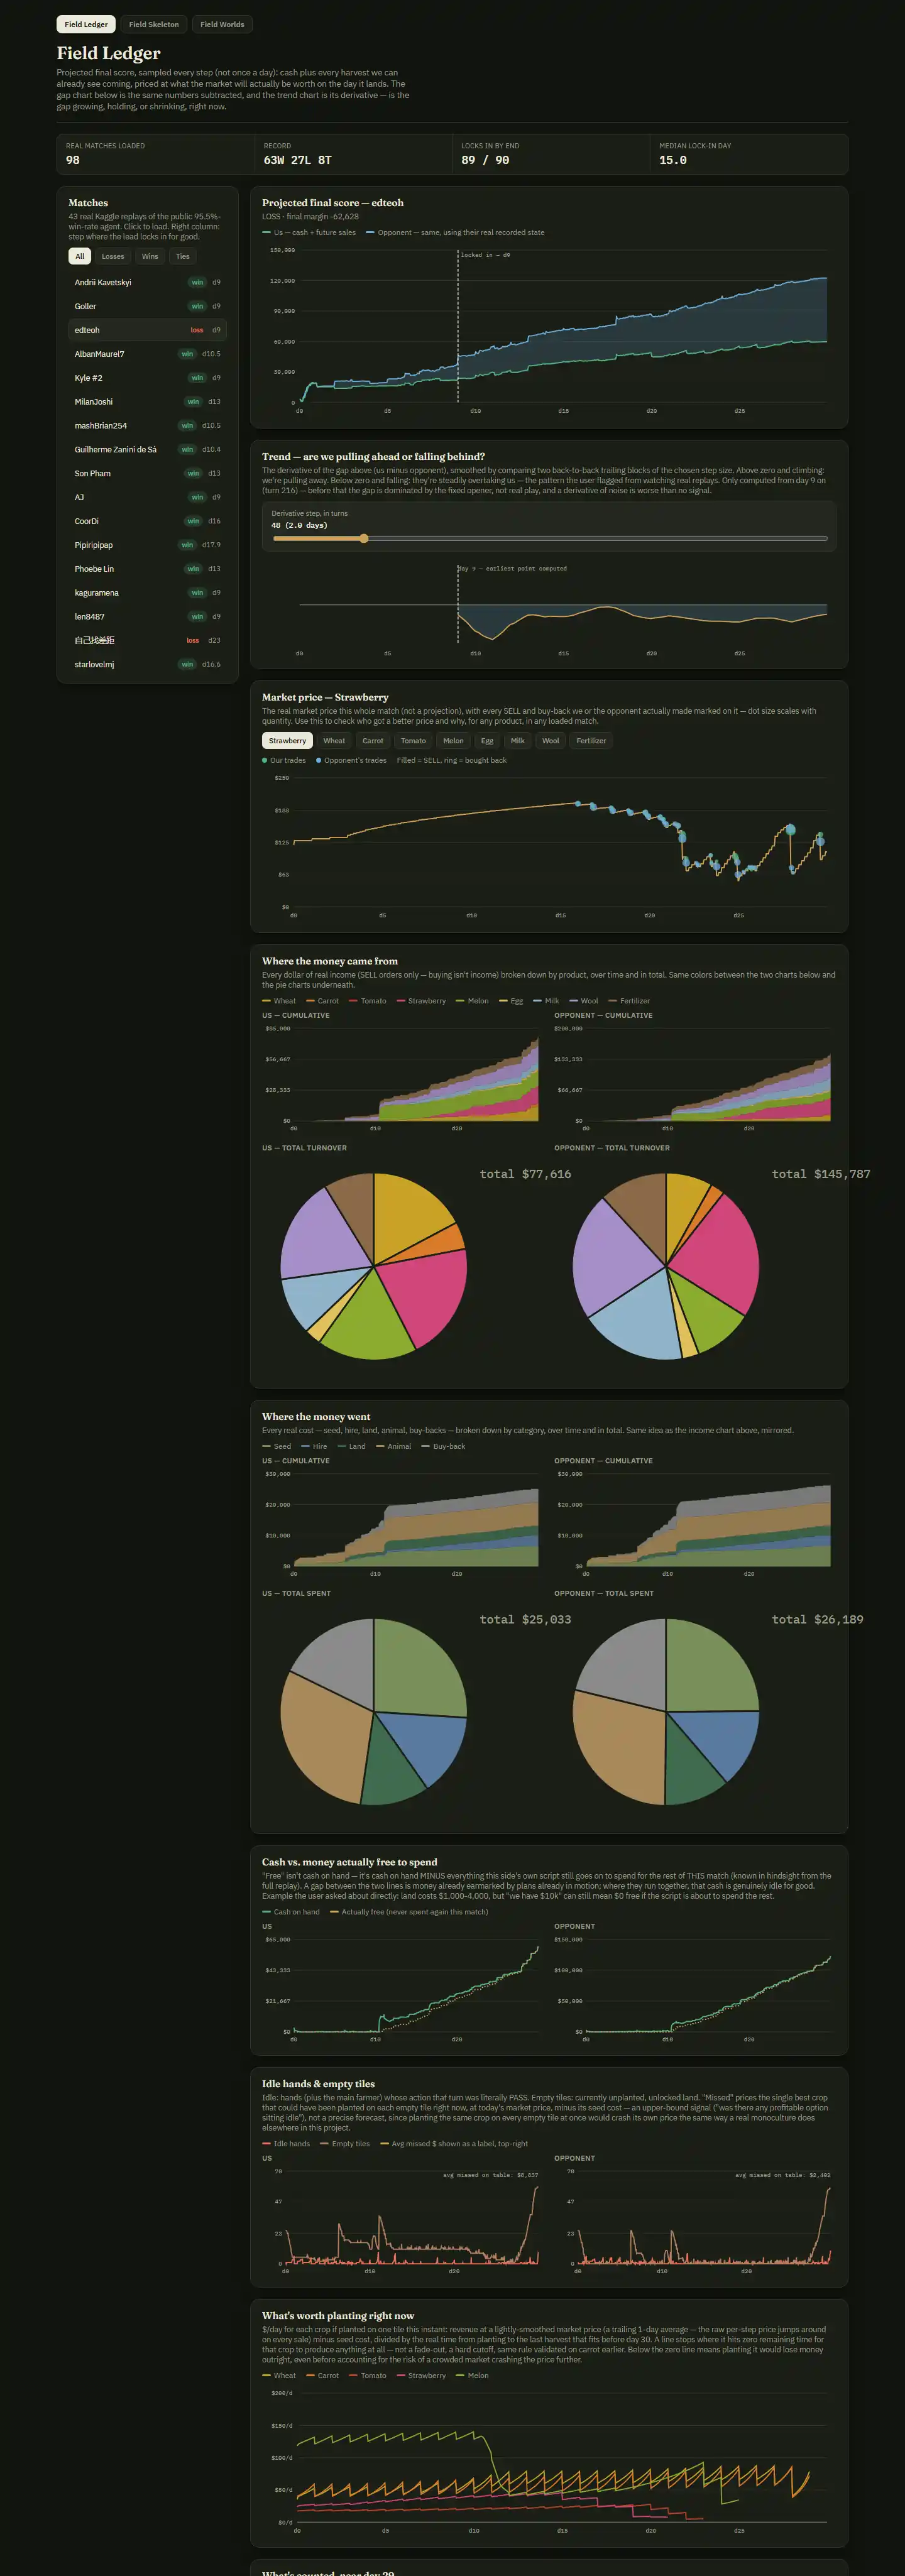

## Field Skeleton

The actual agent map: the day-6 routing branch, observed route frequency and outcomes, route economics, and the games attached to each plan.

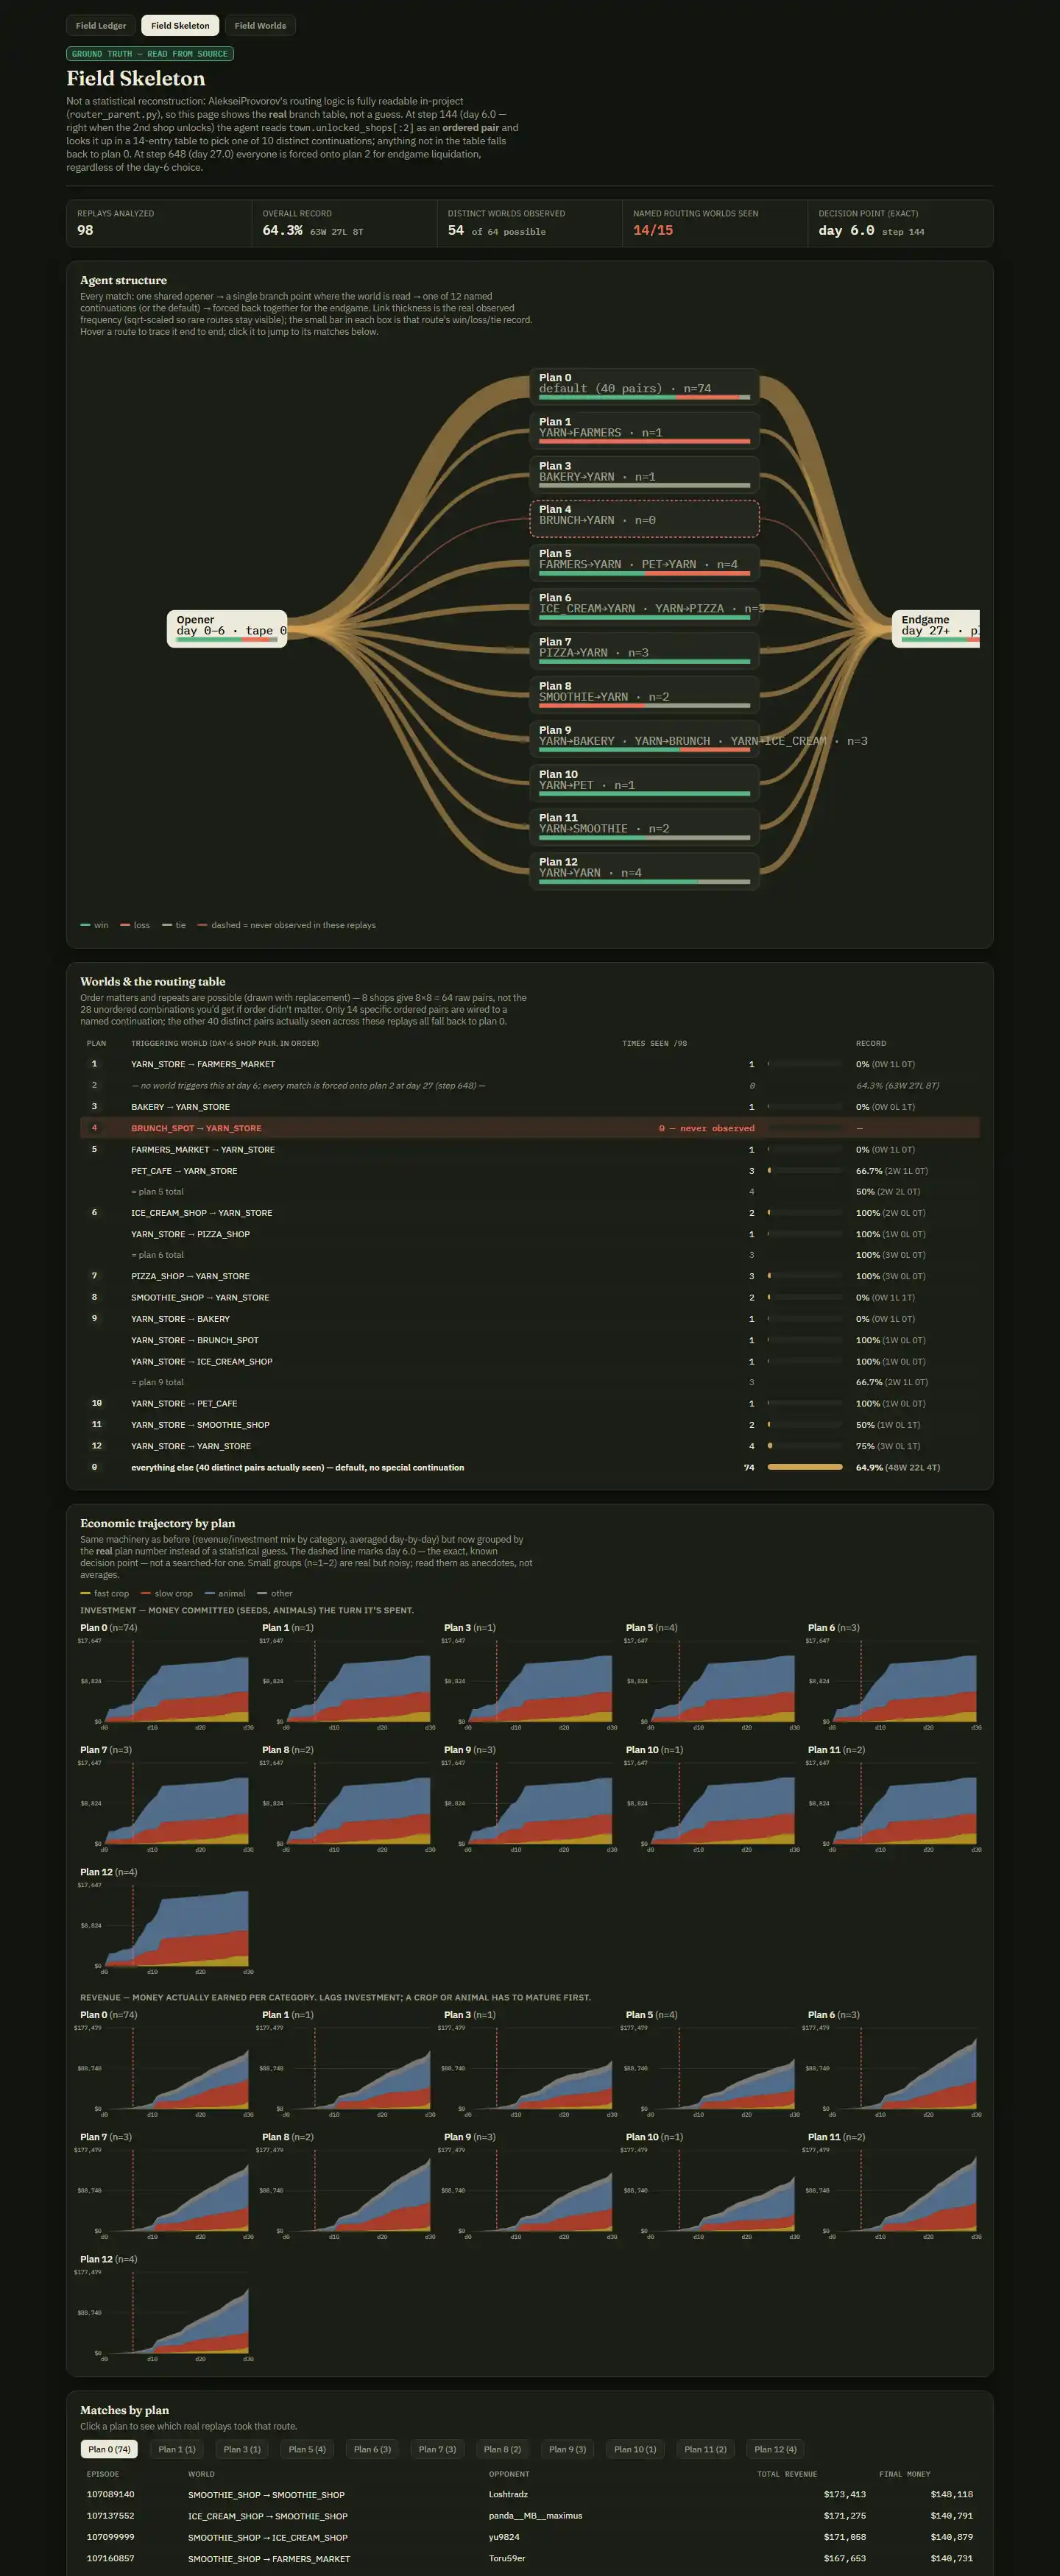

## Field Worlds

All 64 possible shop worlds measured across 2,835 public episodes and cross-checked against the agent's own replay sample.

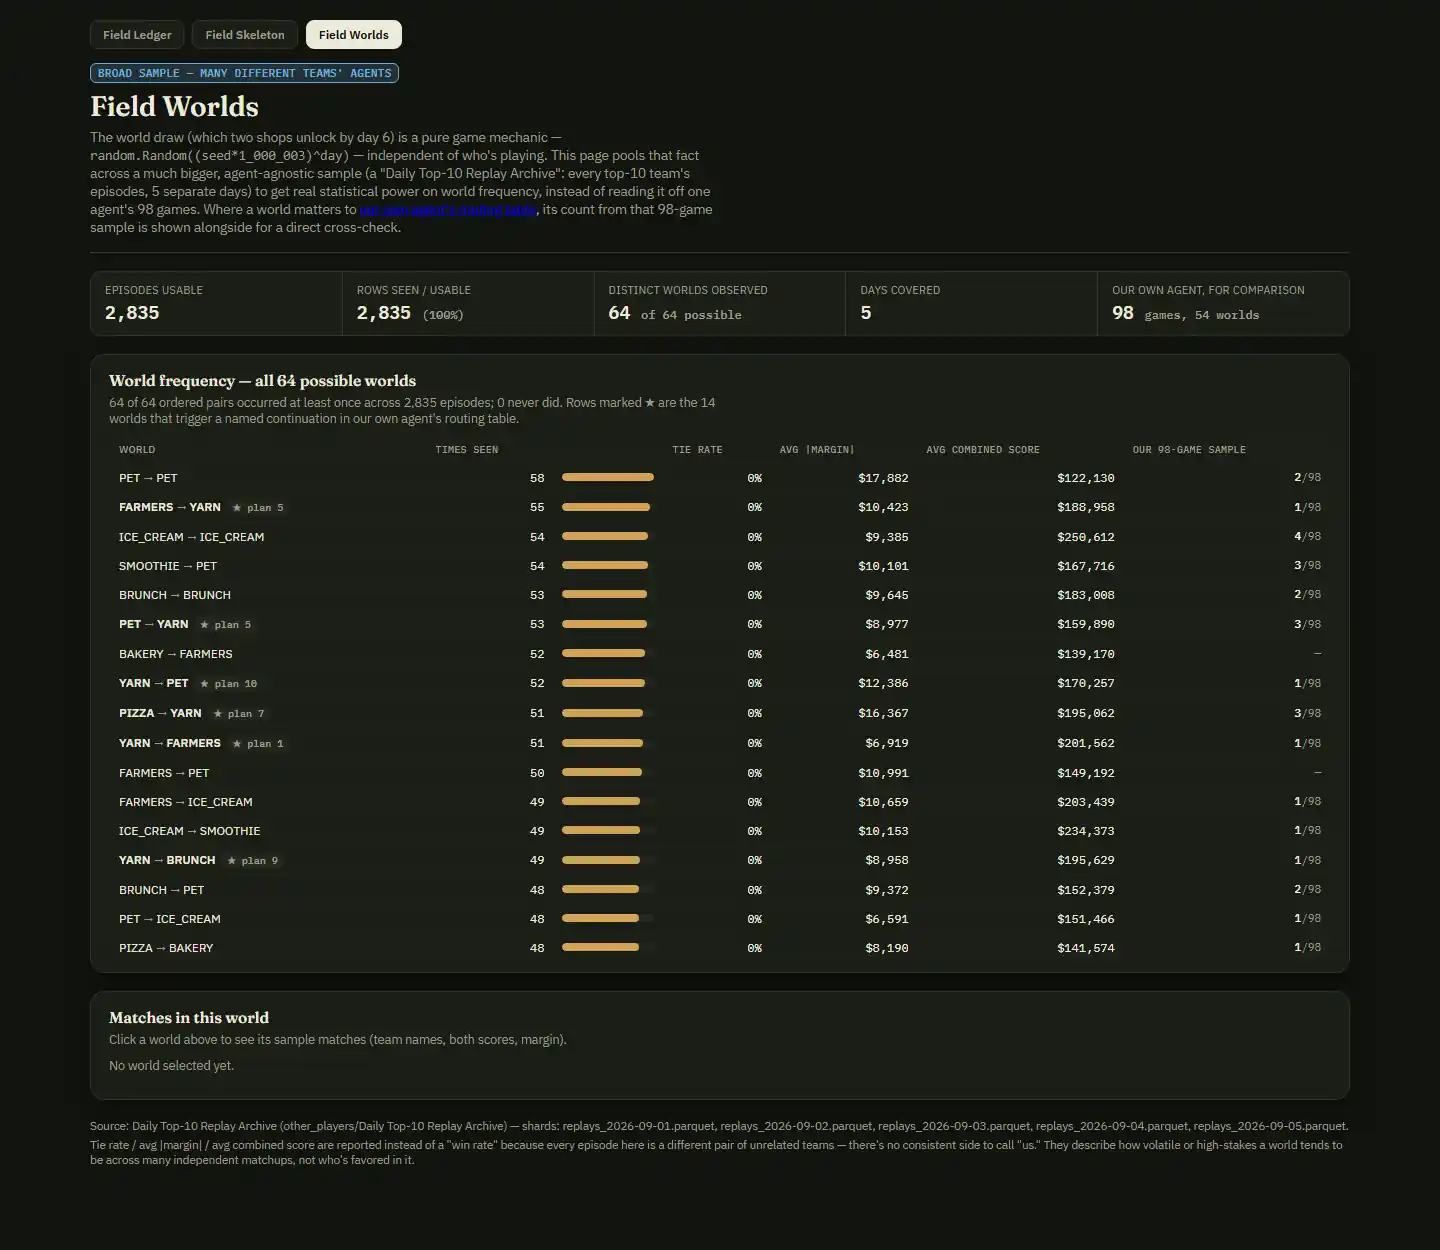

## Reading the agent map

The shared opener runs until **day 6, step 144**. The agent then reads the first two unlocked shops as an ordered pair. Fourteen named pairs select ten distinct continuations; every unlisted pair falls back to plan 0. At **day 27, step 648**, every route enters plan 2 for final liquidation.

The useful unit of analysis is therefore a route inside a world, not one global win rate. The map exposes missing worlds, low-sample branches, route-specific economics, and the exact matches behind each plan.

## Build the exact agent

The hidden cell writes `/kaggle/working/submission.tar.gz` and verifies the deterministic archive hash.

In [ ]:
# Builds MarketShock-M1-WR1K from a hash-checked Kaggle Input. Standard library only.
from pathlib import Path
import gzip, hashlib, importlib.util, io, os, sys, tarfile, zipfile

AGENT_NAME = "MarketShock-M1-WR1K"
DATASET_AGENT_NAME = 'marketshock_m1_wr1k_main.py'
EXPECTED_MAIN_SHA256 = '12ad317ecac6c07fb2c2e10bf4820ecd1fd4551a5a36aa0e34ab93b2c33c2693'
EXPECTED_ARCHIVE_SHA256 = '4d8cf20c2281dca5816eb3615a179a0087f33b10f7f460bbe258741521693461'
INPUT_ROOT = Path(os.environ.get('KAGGLE_INPUT_ROOT', '/kaggle/input'))
if os.environ.get('KAGGLE_WORKING_ROOT'):
    OUTPUT_ROOT = Path(os.environ['KAGGLE_WORKING_ROOT'])
elif os.name != 'nt' and Path('/kaggle/working').is_dir():
    OUTPUT_ROOT = Path('/kaggle/working')
else:
    OUTPUT_ROOT = Path.cwd()

matches = []
if INPUT_ROOT.is_dir():
    # Preferred input: the companion Kaggle Dataset file.
    for candidate in INPUT_ROOT.rglob(DATASET_AGENT_NAME):
        try:
            payload = candidate.read_bytes()
            if hashlib.sha256(payload).hexdigest() == EXPECTED_MAIN_SHA256:
                matches.append((candidate, payload))
        except OSError:
            pass

    # Also accept the prepared ZIP if Kaggle keeps it packed.
    for candidate in INPUT_ROOT.rglob('*.zip'):
        try:
            with zipfile.ZipFile(candidate) as packed:
                names = [name for name in packed.namelist() if Path(name).name == DATASET_AGENT_NAME]
                for name in names:
                    payload = packed.read(name)
                    if hashlib.sha256(payload).hexdigest() == EXPECTED_MAIN_SHA256:
                        matches.append((candidate, payload))
        except (OSError, KeyError, zipfile.BadZipFile):
            pass

    # Alternative input: Output of the self-contained Ice and Fire notebook.
    for candidate in INPUT_ROOT.rglob('submission.tar.gz'):
        try:
            with tarfile.open(candidate, 'r:gz') as archive:
                member = archive.extractfile('main.py')
                if member is None:
                    continue
                payload = member.read()
            if hashlib.sha256(payload).hexdigest() == EXPECTED_MAIN_SHA256:
                matches.append((candidate, payload))
        except (KeyError, OSError, tarfile.TarError):
            pass

if not matches:
    raise FileNotFoundError(
        'Required MarketShock-M1-WR1K input is missing. Attach the Dataset '
        '`marketshock-m1-wr1-agent` (recommended), or attach the Output of the '
        'self-contained Ice and Fire notebook. No hash-matching agent was found.'
    )

SOURCE_INPUT, main_bytes = matches[0]
compile(main_bytes, 'main.py', 'exec')
MAIN = OUTPUT_ROOT / 'main.py'
MAIN.write_bytes(main_bytes)

ARCHIVE = OUTPUT_ROOT / 'submission.tar.gz'
with ARCHIVE.open('wb') as raw:
    with gzip.GzipFile(filename='', mode='wb', fileobj=raw, mtime=0) as zipped:
        with tarfile.open(fileobj=zipped, mode='w', format=tarfile.GNU_FORMAT) as archive:
            info = tarfile.TarInfo('main.py')
            info.size = len(main_bytes); info.mode = 0o644; info.mtime = 0
            info.uid = info.gid = 0; info.uname = info.gname = ''
            archive.addfile(info, io.BytesIO(main_bytes))

assert hashlib.sha256(ARCHIVE.read_bytes()).hexdigest() == EXPECTED_ARCHIVE_SHA256
with tarfile.open(ARCHIVE, 'r:gz') as archive:
    assert archive.getnames() == ['main.py']
    assert archive.extractfile('main.py').read() == main_bytes

sys.path.insert(0, str(OUTPUT_ROOT))
spec = importlib.util.spec_from_file_location('marketshock_m1_wr1k_submission_check', MAIN)
module = importlib.util.module_from_spec(spec); spec.loader.exec_module(module)
assert callable(module.agent)

RECEIPT = OUTPUT_ROOT / 'marketshock_m1_wr1k_build_receipt.json'
RECEIPT.write_text(__import__('json').dumps({
    'agent': AGENT_NAME,
    'source_input': str(SOURCE_INPUT),
    'main_bytes': len(main_bytes),
    'main_sha256': EXPECTED_MAIN_SHA256,
    'archive_bytes': ARCHIVE.stat().st_size,
    'archive_sha256': EXPECTED_ARCHIVE_SHA256,
    'archive_members': ['main.py'],
    'runtime_parent': 'byte-exact Kaggriculture: A Smaller Market Shock',
}, indent=2), encoding='utf-8')

print('READY_TO_SUBMIT', AGENT_NAME)
print('Agent input:', SOURCE_INPUT)
print('Archive:', ARCHIVE)
print('Archive bytes:', ARCHIVE.stat().st_size)
print('Archive SHA-256:', EXPECTED_ARCHIVE_SHA256)
print('Root main.py:', MAIN)
print('Build receipt:', RECEIPT)


## Continue the experiment

Upvote if you want the full toolkit and more replay studies published. Put public notebook links, episode links, and concrete mechanism ideas in the comments. For collaboration, contact me on Kaggle or [LinkedIn](https://rs.linkedin.com/in/aleksei-provorov-832050308).